# exercise 5: pdb Ramachandran Plot (phi-psi map)

In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import gzip
import matplotlib.pyplot as plt

In [4]:
data_dir = '/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_3/pisces/pdb'

list_file = data_dir + '/list.txt'
pdb_list = [x.strip().split() for x in open(list_file)]

In [5]:
main_atom_list = [' N  ', ' CA ', ' C  ', ' O  ']
Res31 = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',
         'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',
         'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',
         'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y', }
res_list = Res31.keys()

In [6]:
def read_pdb(pdb_file):
    fp = gzip.open(pdb_file)
    lines = fp.readlines()
    fp.close()
    chain_dict = dict()
    atom_coor_dict = dict()

    check_m = False
    modres_dict = dict()
    for line_b in lines:
        line = line_b.decode('ascii')
        if line[0:10] == 'REMARK 465':
            if line[15:27] == 'RES C SSSEQI':
                check_m = True
                continue
            if check_m:
                res_name3 = line[15:18]
                res_inser = line[22:27]
                chain_id = line[19]
                if chain_id not in chain_dict:
                    chain_dict[chain_id] = dict()
                    atom_coor_dict[chain_id] = dict()
                chain_dict[chain_id][res_inser] = res_name3
                atom_coor_dict[chain_id][res_inser] = dict()

        elif line[0:6] == 'MODRES':
            res_name3_mod = line[12:15]
            res_name3 = line[24:27]
            if res_name3_mod not in modres_dict and res_name3 in Res31:
                modres_dict[res_name3_mod] = res_name3

        elif line[0:6] == 'ATOM  ':
            chain_id = line[21]
            res_name3 = line[17:20]
            res_inser = line[22:27]

            alt_loc = line[16]
            if alt_loc != ' ' and alt_loc != 'A':
                continue

            if chain_id not in chain_dict:
                chain_dict[chain_id] = dict()
                atom_coor_dict[chain_id] = dict()
            if res_name3 not in Res31:
                continue
            if res_inser not in chain_dict[chain_id]:
                chain_dict[chain_id][res_inser] = res_name3
                atom_coor_dict[chain_id][res_inser] = dict()

            atom_name = line[12:16]

            if atom_name in main_atom_list:
                coor = (line[30:38], line[38:46], line[46:54])
                coor = np.array(coor, dtype=np.float64)
                atom_coor_dict[chain_id][res_inser][atom_name] = coor

        elif line[0:6] == 'HETATM':
            chain_id = line[21]
            res_name3 = line[17:20]
            res_inser = line[22:27]
            alt_loc = line[16]
            if alt_loc != ' ' and alt_loc != 'A':
                continue

            if chain_id not in chain_dict:
                chain_dict[chain_id] = dict()
                atom_coor_dict[chain_id] = dict()
            if res_name3 not in modres_dict:
                continue

            if res_inser not in chain_dict[chain_id]:
                chain_dict[chain_id][res_inser] = res_name3
                atom_coor_dict[chain_id][res_inser] = dict()

            atom_name = line[12:16]
            if atom_name in main_atom_list:
                coor = (line[30:38], line[38:46], line[46:54])
                coor = np.array(coor, dtype=np.float64)
                atom_coor_dict[chain_id][res_inser][atom_name] = coor

    return chain_dict, atom_coor_dict, modres_dict

In [7]:
def cal_angle(pos_1, pos_2, pos_3):
    va = pos_1 - pos_2
    vb = pos_3 - pos_2
    vc = va + vb
    a2 = va.dot(va)
    b2 = vb.dot(vb)
    a = np.sqrt(a2)
    b = np.sqrt(b2)
    c2 = vc.dot(vc)
    cos_angle = (c2 - a2 - b2) / (2*a*b)
    angle = np.arccos(cos_angle)
    return 180 * angle / np.pi

In [8]:
def cal_normal_vector(pos_1, pos_2, pos_3):
    va = pos_2 - pos_1
    vb = pos_3 - pos_2
    vp = np.cross(va, vb)
    p = np.linalg.norm(vp)
    return vp/p

In [9]:
def cal_torsional_angle(pos_1, pos_2, pos_3, pos_4):
    na = cal_normal_vector(pos_1, pos_2, pos_3)
    nb = cal_normal_vector(pos_2, pos_3, pos_4)
    vc = nb+na
    a2 = na.dot(na)
    b2 = nb.dot(nb)
    a = np.sqrt(a2)
    b = np.sqrt(b2)
    c2 = vc.dot(vc)
    cos_angle = (c2 - a2 - b2) / (2*a*b)

    vd = np.cross(na, nb)
    nd = vd/np.linalg.norm(vd)
    v32 = pos_3-pos_2
    n32 = v32/np.linalg.norm(v32)
    z = n32.dot(nd)
    angle = np.arccos(cos_angle)
    angle2 = z*180 * angle / np.pi

    return angle2

In [10]:
def cal_single(chain_dict, atom_coor_dict, modres_dict, chain_id, res_angle_dict):
    keys = sorted(chain_dict[chain_id].keys())
    num_keys = len(keys)
    for i in range(num_keys):
        key = keys[i]
        res_name = chain_dict[chain_id][key]
        if res_name in modres_dict:
            res_name = modres_dict[res_name]

        res_dict = atom_coor_dict[chain_id][key]
        if ' N  ' in res_dict:
            pos_n = res_dict[' N  ']
        else:
            continue
        if ' CA ' in res_dict:
            pos_ca = res_dict[' CA ']
        else:
            continue
        if ' C  ' in res_dict:
            pos_c = res_dict[' C  ']
        else:
            continue

        angle = cal_angle(pos_n, pos_ca, pos_c)
        if i != 0:
            key_m = keys[i-1]
            res_m_dict = atom_coor_dict[chain_id][key_m]
            if ' C  ' in res_m_dict:
                pos_cm = res_m_dict[' C  ']
                phi = cal_torsional_angle(pos_cm, pos_n, pos_ca, pos_c)
            else:
                phi = None
        else:
            phi = None
        if i != num_keys-1:
            key_p = keys[i+1]
            res_p_dict = atom_coor_dict[chain_id][key_p]
            if ' N  ' in res_p_dict:
                pos_np = res_p_dict[' N  ']
                psi = cal_torsional_angle(pos_n, pos_ca, pos_c, pos_np)

            else:
                psi = None
        else:
            psi = None

        if angle is not None and phi is not None and psi is not None:
            res_angle_dict[res_name] += [[angle, phi, psi]]

In [12]:
import urllib.request
import os

res_angle_dict = dict()
for res_name in res_list:
    res_angle_dict[res_name] = list()

num_pdb = len(pdb_list)
for i in range(0, num_pdb):
    pdb_id = pdb_list[i][0]
    chain_id = pdb_list[i][1]

    # 1. 하위 폴더 자동 생성 및 PDB 파일 다운로드
    sub_dir = '%s/%s' % (data_dir, pdb_id[0])
    pdb_file = '%s/%s.pdb.gz' % (sub_dir, pdb_id)

    if not os.path.exists(sub_dir):
        os.makedirs(sub_dir, exist_ok=True)

    if not os.path.exists(pdb_file):
        url = f'https://files.rcsb.org/download/{pdb_id}.pdb.gz'
        try:
            urllib.request.urlretrieve(url, pdb_file)
        except Exception as e:
            print(f'다운로드 실패 {pdb_id}: {e}')
            continue

    chain_dict, atom_coor_dict, modres_dict = read_pdb(pdb_file)

    # 2. 사슬(Chain)이 존재하지 않으면 에러를 띄우지 않고 건너뛰기
    if chain_id not in chain_dict:
        continue

    cal_single(chain_dict, atom_coor_dict, modres_dict, chain_id, res_angle_dict)

print("라마찬드란 플롯용 이면각 데이터 수집 완료!")

다운로드 실패 4V4M: HTTP Error 404: Not Found
다운로드 실패 6TAK: HTTP Error 404: Not Found
다운로드 실패 6TN5: HTTP Error 404: Not Found
다운로드 실패 6TWO: HTTP Error 404: Not Found
다운로드 실패 6XY7: HTTP Error 404: Not Found
다운로드 실패 7AF2: HTTP Error 404: Not Found
다운로드 실패 7AVC: HTTP Error 404: Not Found
다운로드 실패 7B6A: HTTP Error 404: Not Found
다운로드 실패 7M1A: HTTP Error 404: Not Found
다운로드 실패 7NQG: HTTP Error 404: Not Found
다운로드 실패 7NZD: HTTP Error 404: Not Found
다운로드 실패 7OLW: HTTP Error 404: Not Found
다운로드 실패 7OMV: HTTP Error 404: Not Found
다운로드 실패 7OS5: HTTP Error 404: Not Found
다운로드 실패 7OST: HTTP Error 404: Not Found
다운로드 실패 7P24: HTTP Error 404: Not Found
다운로드 실패 7P5R: HTTP Error 404: Not Found
다운로드 실패 7PJ4: HTTP Error 404: Not Found
다운로드 실패 7Q4T: HTTP Error 404: Not Found
다운로드 실패 7QYM: HTTP Error 404: Not Found
다운로드 실패 7QYM: HTTP Error 404: Not Found
라마찬드란 플롯용 이면각 데이터 수집 완료!


<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_740/2797417644.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi$ (phi)')
/tmp/ipykernel_740/2797417644.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$ (psi)')


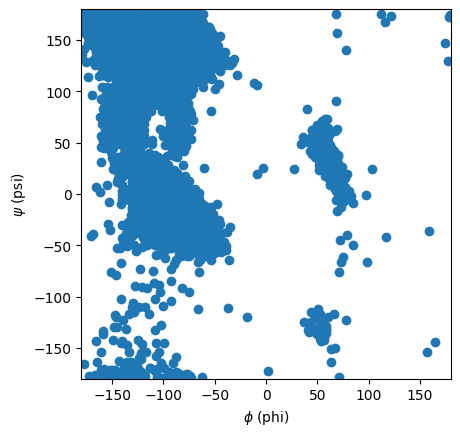

In [13]:
rama = np.array(res_angle_dict['ALA'])
fig1, ax = plt.subplots()
ax.set_box_aspect(1)
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xlabel('$\phi$ (phi)')
plt.ylabel('$\psi$ (psi)')
plt.scatter(rama[:, 1], rama[:, 2])

*   (알라닌, ALA)

가장 표준적인 아미노산의 형태학적 자유도를 보여주는 일반적인 라마찬드란 플롯입니다.

좌측 상단의 베타 병풍 영역($\phi$ < 0, $\psi$ > 0)과 좌측 하단의 우상향 알파 나선 영역($\phi$ < 0, $\psi$ < 0)에 점들이 고밀도로 밀집해 있습니다.

우측 평면($\phi$ > 0)은 측쇄 원자와 카보닐 산소 간의 입체적 충돌(Steric clash) 때문에 구조적으로 매우 불안정하여 좌상향 나선 등 극히 일부를 제외하고는 데이터가 비어 있습니다.

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_740/238844261.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi$ (phi)')
/tmp/ipykernel_740/238844261.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$ (psi)')


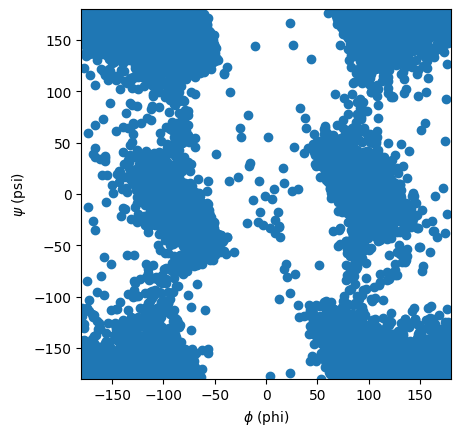

In [14]:
rama = np.array(res_angle_dict['GLY'])
fig1, ax = plt.subplots()
ax.set_box_aspect(1)
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xlabel('$\phi$ (phi)')
plt.ylabel('$\psi$ (psi)')
plt.scatter(rama[:, 1], rama[:, 2])

*   (글라이신, GLY)

구조적 유연성이 가장 큰 아미노산인 글라이신의 분포입니다.

글라이신은 측쇄(R기)가 부피가 가장 작은 수소(H) 원자 하나뿐이므로, 단백질 뼈대를 이리저리 비틀어도 원자들끼리 부딪히는 입체적 충돌이 거의 발생하지 않습니다.

그 결과, 다른 일반적인 아미노산들은 가질 수 없는 우측 영역(1, 4사분면)까지 포함하여 평면의 거의 모든 구역에 점들이 넓고 대칭적으로 퍼져 나타납니다.

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_740/1005678688.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi$ (phi)')
/tmp/ipykernel_740/1005678688.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\psi$ (psi)')


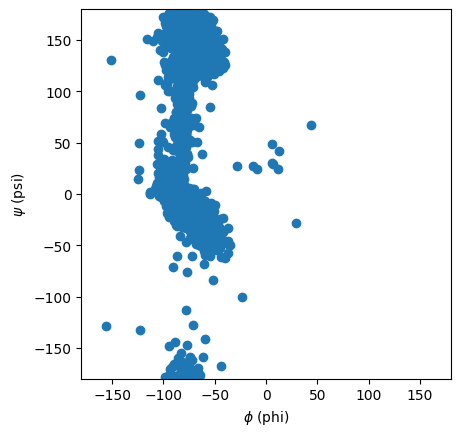

In [15]:
rama = np.array(res_angle_dict['PRO'])
fig1, ax = plt.subplots()
ax.set_box_aspect(1)
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xlabel('$\phi$ (phi)')
plt.ylabel('$\psi$ (psi)')
plt.scatter(rama[:, 1], rama[:, 2])

*   (프롤린, PRO)

단백질에서 구조적 제약이 가장 심한 프롤린의 극단적인 분포입니다.

프롤린은 측쇄가 뼈대의 아미드 질소(N) 원자와 다시 결합하여 단단한 5원환 고리(Pyrrolidine ring)를 형성합니다.

이 고리 구조가 N-C$\alpha$ 결합 축의 회전을 물리적으로 완전히 잠가버리기 때문에, 프싸이($\psi$) 각도의 변화와 무관하게 파이($\phi$) 각도가 약 -50°에서 -90° 사이의 매우 좁은 수직 띠 형태의 구간에만 갇혀서 나타납니다.